# CPC-Tiny (ViT)

**CPC (Contrastive Predictive Coding)** is a self-supervised learning (SSL) method that is **contrastive** and predicts in **latent space** (not pixel space like MAE). It splits the image into a grid of patches, builds a context vector $c_t$ from the top rows, and predicts the latent representations $z_{t+k}$ of the bottom rows with an InfoNCE contrastive loss.

The key object is the **density ratio** estimated by a log-bilinear score (van den Oord et al., 2018, Eq 3) :

$$f_k(z_{t+k}, c_t) = \exp(z_{t+k}^T W_k\, c_t) \;\propto\; \frac{p(z_{t+k} \mid c_t)}{p(z_{t+k})}$$

Pre-trained on STL-10 unlabeled, evaluated on CIFAR-10 with both linear probe and full fine-tune.

**Differences vs the original paper** : (1) the paper uses a per-patch CNN + a PixelCNN; here we use a **bidirectional ViT with a block-diagonal attention mask** (context and target cannot attend to each other) to avoid leakage, encoding all 64 patches in a single pass. (2) the paper produces a context at every grid position; here we collapse the context to a single $c_t$ (last token of a causal Transformer) and predict the 4 bottom rows from it. See `4_CPC_paper` for the paper-faithful version (CNN per patch + causal row-GRU).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import os

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "DATA"))
CKPT_DIR = './checkpoints/5_CPC_vit'
os.makedirs(CKPT_DIR, exist_ok=True)

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device = {device}")

device = cuda


---
# 0. Dataset

STL-10 unlabeled (100k train / 8k test) for self-supervised pre-training. CIFAR-10 (50k train / 10k test) for downstream evaluation (linear probe + fine-tune).

In [2]:
BATCH_SIZE = 128
IMG_SIZE   = 32
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

pretrain_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
train_probe_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

pretrain_set = torchvision.datasets.STL10(root=DATA_DIR, split='unlabeled', download=True, transform=pretrain_tf)
train_dataset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_probe_tf)
test_dataset  = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_tf)

pretrain_loader = DataLoader(pretrain_set,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
train_loader    = DataLoader(train_dataset,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader     = DataLoader(test_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_img, _ = train_dataset[0]
CHANNELS, H, W = sample_img.shape
NUM_CLASSES    = len(train_dataset.classes)

print("── Pre-training (STL-10, self-supervised) ──")
print(f"  train (unlabeled) : {len(pretrain_set):>6}")
print()
print("── Downstream (CIFAR-10, supervised) ──")
print(f"  train             : {len(train_dataset):>6}")
print(f"  test              : {len(test_dataset):>6}")
print()
print(f"CIFAR-10 classes : {train_dataset.classes}")

── Pre-training (STL-10, self-supervised) ──
  train (unlabeled) : 100000

── Downstream (CIFAR-10, supervised) ──
  train             :  50000
  test              :  10000

CIFAR-10 classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
# 1. CPC architecture

### Encoder $g_{\text{enc}}$ : ViT-Tiny on the full image (block-masked)

A single ViT-Tiny encodes all 64 patches at once. A **block-diagonal attention mask** prevents the context (top 4 rows) and the target (bottom 4 rows) from attending to each other → no leakage. This is mathematically equivalent to encoding the two halves separately, but in one pass and with **distinct positional embeddings** for all 64 patches.

| Step | Operation | Shape (symbolic) | Shape (numeric) |
|---|---|---|---|
| Input | image | $(B, \text{channels}, \text{img\_size}, \text{img\_size})$ | $(B, 3, 32, 32)$ |
| Patchify + linear projection | `patchify` + `nn.Linear(patch_dim, d_model)` | $(B, n_{\text{patches}}, \text{d\_model})$ | $(B, 64, 128)$ |
| Add positional embeddings (64 distinct) | $x + E_{\text{pos}}$ | $(B, n_{\text{patches}}, \text{d\_model})$ | $(B, 64, 128)$ |
| `num_layers` × Transformer blocks (Pre-LN, **block-masked**) | `nn.TransformerEncoder` | $(B, n_{\text{patches}}, \text{d\_model})$ | $(B, 64, 128)$ |
| LayerNorm | `nn.LayerNorm(d_model)` | $(B, n_{\text{patches}}, \text{d\_model})$ | $(B, 64, 128)$ |
| Split | context = first 32, target = last 32 | $(B, 32, D)$ each | $(B, 32, 128)$ |

### Autoregressive model $g_{\text{ar}}$ : causal Transformer

Summarizes the 32 context patches into a single context vector $c_t$ (last token of a causal Transformer).

| Step | Operation | Shape (symbolic) | Shape (numeric) |
|---|---|---|---|
| Input | context patch latents | $(B, 32, \text{d\_model})$ | $(B, 32, 128)$ |
| Add positional embeddings | $x + E_{\text{pos}}^{\text{ar}}$ | $(B, 32, \text{d\_model})$ | $(B, 32, 128)$ |
| 2 × causal Transformer blocks | `nn.TransformerEncoder` | $(B, 32, \text{d\_model})$ | $(B, 32, 128)$ |
| LayerNorm + take last token | `x[:, -1, :]` | $(B, \text{d\_model})$ | $(B, 128)$ → $c_t$ |

### Prediction heads + InfoNCE

For each future row $k = 1, \dots, N_{\text{predict}}$ : predict $W_k\, c_t$ and contrast it against the true latents $z_{t+k}$ of that row, with the same-position patches of the other batch images as negatives.

$$\mathcal{L}_N = -\mathbb{E}\left[\log \frac{\exp(z_{t+k}^T W_k c_t)}{\sum_{j} \exp(z_j^T W_k c_t)}\right]$$

| Hyperparameter | Symbol | Value |
|---|---|---|
| Encoder/AR model dim | `d_model` | 128 |
| Heads | `num_heads` | 4 |
| Encoder layers | `num_layers` | 6 |
| AR layers | (fixed) | 2 |
| FFN dim | `d_ff` | 512 |
| Context rows | `n_context_rows` | 4 |
| Rows to predict | `n_predict` | 4 |

### The block-diagonal attention mask

The encoder is a ViT, so attention is bidirectional — every patch can attend to every other patch. To prevent leakage between context and target, we add a **mask** $M$ to the attention scores :

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^T}{\sqrt{d}} + M\right) V$$

where $M_{ij} \in \{0, -\infty\}$. A $-\infty$ entry sends $\exp(\cdot) \to 0$ in the softmax, so token $i$ puts **zero attention weight** on token $j$.

Index the 64 patches so that $0, \dots, 31$ are the context (top 4 rows) and $32, \dots, 63$ are the target (bottom 4 rows). The block-diagonal mask is :

$$M_{ij} = \begin{cases} -\infty & \text{if } i < 32 \text{ and } j \geq 32 \quad (\text{context} \to \text{target}) \\ -\infty & \text{if } i \geq 32 \text{ and } j < 32 \quad (\text{target} \to \text{context}) \\ 0 & \text{otherwise} \end{cases}$$

In block form :

$$M = \begin{pmatrix} 0_{32\times 32} & -\infty_{32\times 32} \\ -\infty_{32\times 32} & 0_{32\times 32} \end{pmatrix}$$

**Effect** : context patches only attend to context, target patches only attend to target. The two halves are encoded independently — same guarantee as a two-pass split, but in a single pass with distinct positional embeddings for all 64 patches.

**Why both directions are blocked** : the target latents $z_{t+k}$ are the **ground truth** to predict, so they must not depend on the context — otherwise predicting them from $c_t$ would be trivial (the target would already encode the context). A purely causal mask (target sees context) would leak ; only the block-diagonal mask is fully clean.

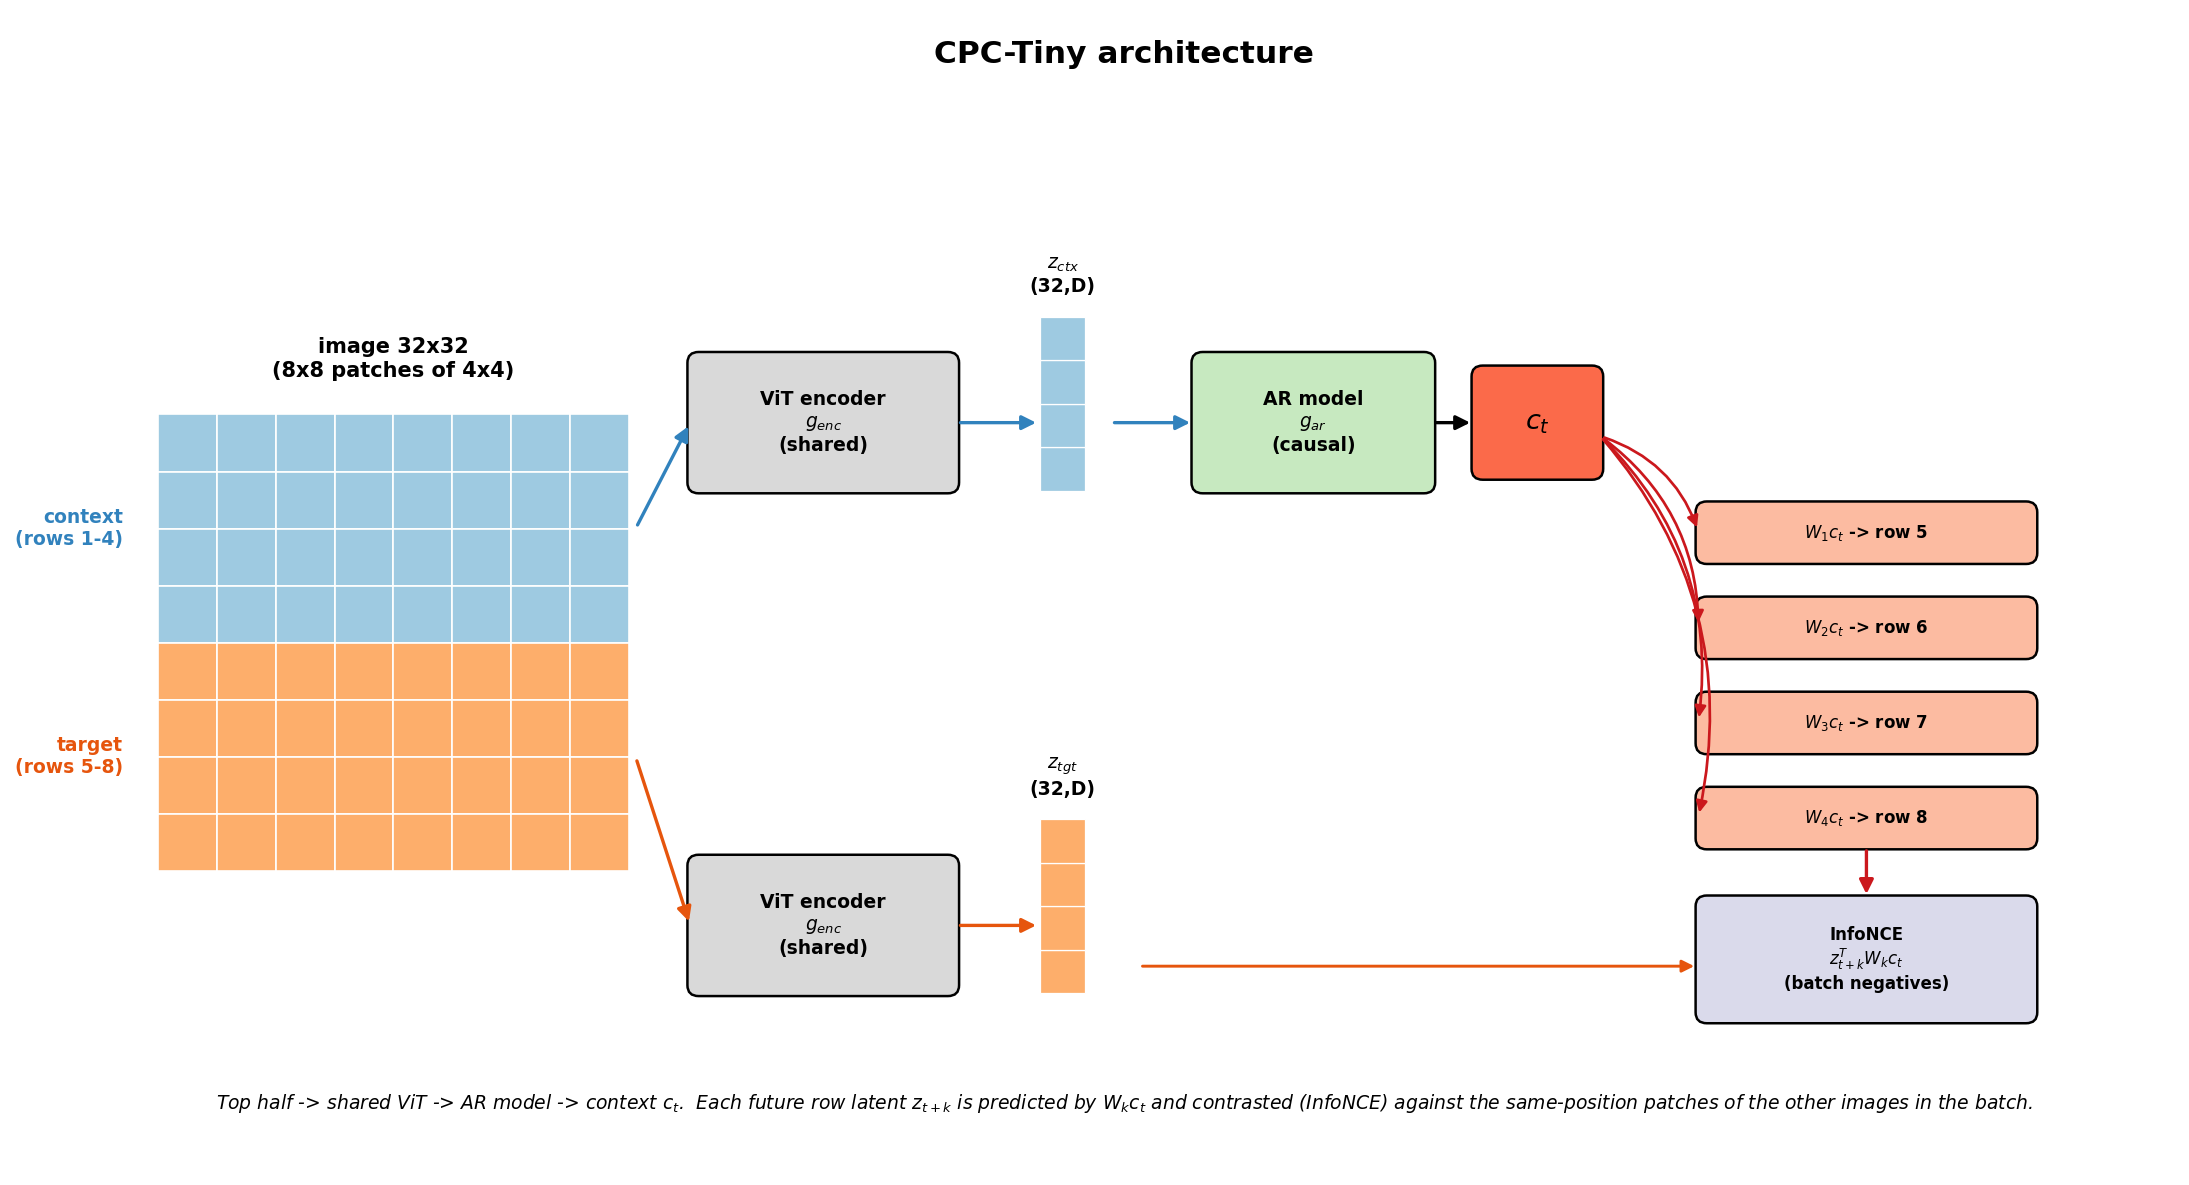

## Hyperparameters

In [3]:
PATCH_SIZE  = 4
GRID_SIZE   = IMG_SIZE // PATCH_SIZE     # 8
N_PATCHES   = GRID_SIZE ** 2             # 64
PATCH_DIM   = PATCH_SIZE ** 2 * CHANNELS # 48

D_MODEL    = 128
NUM_HEADS  = 4
NUM_LAYERS = 6
D_FF       = 4 * D_MODEL                 # 512
DROPOUT    = 0.1

AR_LAYERS      = 2
N_CONTEXT_ROWS = 4
N_PREDICT      = GRID_SIZE - N_CONTEXT_ROWS   # 4

PRETRAIN_EPOCHS = 20
PROBE_EPOCHS    = 60
FT_EPOCHS       = 60

print(f"N_PATCHES        = {N_PATCHES}")
print(f"patches per half = {N_CONTEXT_ROWS * GRID_SIZE}")
print(f"rows to predict  = {N_PREDICT}")

N_PATCHES        = 64
patches per half = 32
rows to predict  = 4


In [4]:
def patchify(images, patch_size):  # images(B,C,H,W)
    B, C, H, W = images.shape
    P = patch_size
    x = images.reshape(B, C, H // P, P, W // P, P)
    x = x.permute(0, 2, 4, 3, 5, 1)
    x = x.reshape(B, (H // P) * (W // P), P * P * C)
    return x   # (B, N, patch_dim)


def unnormalize(img):
    mean = torch.tensor(MEAN).view(3, 1, 1).to(img.device)
    std  = torch.tensor(STD).view(3, 1, 1).to(img.device)
    return (img * std + mean).clamp(0, 1)

In [5]:
class FullImageViT(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.projection    = nn.Linear(PATCH_DIM, D_MODEL)
        self.pos_embedding = nn.Parameter(torch.randn(1, N_PATCHES, D_MODEL) * 0.02)   # 64 distinct positions
        self.dropout       = nn.Dropout(DROPOUT)
        block = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=NUM_HEADS, dim_feedforward=D_FF,
                                            dropout=DROPOUT, activation='gelu',
                                            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(block, num_layers=NUM_LAYERS)
        self.norm = nn.LayerNorm(D_MODEL)

        # block-diagonal mask : context (first n_ctx) and target (rest) cannot attend to each other
        n_ctx = N_CONTEXT_ROWS * GRID_SIZE   # 32
        mask = torch.zeros(N_PATCHES, N_PATCHES, dtype=torch.bool)
        mask[:n_ctx, n_ctx:] = True   # context cannot see target
        mask[n_ctx:, :n_ctx] = True   # target cannot see context
        self.register_buffer('attn_mask', mask)

    def forward(self, images):                        # (B, 3, 32, 32)
        x = patchify(images, PATCH_SIZE)               # (B, 64, patch_dim)
        x = self.projection(x) + self.pos_embedding    # (B, 64, D)
        x = self.dropout(x)
        x = self.transformer(x, mask=self.attn_mask)   # block-diagonal attention
        return self.norm(x)                            # (B, 64, D)


class ARModel(nn.Module):
   
    def __init__(self):
        super().__init__()
        n_ctx = N_CONTEXT_ROWS * GRID_SIZE   # 32
        self.pos = nn.Parameter(torch.randn(1, n_ctx, D_MODEL) * 0.02)
        block = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=NUM_HEADS, dim_feedforward=D_FF,
                                            dropout=DROPOUT, activation='gelu',
                                            batch_first=True, norm_first=True)
        self.tr = nn.TransformerEncoder(block, num_layers=AR_LAYERS)
        self.norm = nn.LayerNorm(D_MODEL)
        mask = nn.Transformer.generate_square_subsequent_mask(n_ctx)
        self.register_buffer('mask', mask)

    def forward(self, z_ctx):                          # (B, 32, D)
        x = z_ctx + self.pos
        x = self.tr(x, mask=self.mask, is_causal=True)
        return self.norm(x)[:, -1, :]                  # (B, D) = c_t


class CPC(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = FullImageViT()
        self.ar      = ARModel()
        self.W = nn.ModuleList([nn.Linear(D_MODEL, D_MODEL, bias=False) for _ in range(N_PREDICT)])

    def forward(self, images):
        n_ctx = N_CONTEXT_ROWS * GRID_SIZE             # 32
        z = self.encoder(images)                       # (B, 64, D)  single pass, block-masked
        z_ctx = z[:, :n_ctx, :]                        # (B, 32, D)  context patches
        z_tgt = z[:, n_ctx:, :]                        # (B, 32, D)  target patches
        c = self.ar(z_ctx)                             # (B, D)  context vector

        B = images.shape[0]
        labels = torch.arange(B, device=images.device)
        loss = 0.0
        for k in range(N_PREDICT):
            pred   = self.W[k](c)                                  # (B, D)
            target = z_tgt[:, k * GRID_SIZE:(k + 1) * GRID_SIZE, :]  # (B, 8, D) row k
            li = 0.0
            for g in range(GRID_SIZE):
                logits = pred @ target[:, g, :].T                 # (B, B)
                li = li + F.cross_entropy(logits, labels)
            loss = loss + li / GRID_SIZE
        return loss / N_PREDICT


cpc = CPC().to(device)

params = sum(p.numel() for p in cpc.parameters())

def transformer_block(d, d_ff):
    attn = 4 * d * d + 4 * d
    ffn  = 2 * d * d_ff + d_ff + d
    lns  = 2 * (2 * d)
    return attn + ffn + lns

# encoder g_enc (full image : 64 positional embeddings; the block mask is a buffer = 0 params)
enc_proj   = PATCH_DIM * D_MODEL + D_MODEL
enc_pos    = N_PATCHES * D_MODEL
enc_blocks = NUM_LAYERS * transformer_block(D_MODEL, D_FF)
enc_norm   = 2 * D_MODEL
encoder_params = enc_proj + enc_pos + enc_blocks + enc_norm

# AR model g_ar
n_half = N_CONTEXT_ROWS * GRID_SIZE
ar_pos    = n_half * D_MODEL
ar_blocks = AR_LAYERS * transformer_block(D_MODEL, D_FF)
ar_norm   = 2 * D_MODEL
ar_params = ar_pos + ar_blocks + ar_norm

# prediction heads W_k (no bias)
w_params = N_PREDICT * (D_MODEL * D_MODEL)

params_th = encoder_params + ar_params + w_params

print(f"encoder params : {encoder_params:,}")
print(f"AR params      : {ar_params:,}")
print(f"W_k params     : {w_params:,}")
print(f"empirical : {params:,}")
print(f"theory    : {params_th:,}")
print(f"match     : {params == params_th}")

C:\Users\hugop\AppData\Local\Temp\ipykernel_7908\711145984.py:11: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(block, num_layers=NUM_LAYERS)
C:\Users\hugop\AppData\Local\Temp\ipykernel_7908\711145984.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(block, num_layers=AR_LAYERS)


encoder params : 1,204,352
AR params      : 400,896
W_k params     : 65,536
empirical : 1,670,784
theory    : 1,670,784
match     : True


---
# 2. Pre-training on STL-10

In [6]:
PRETRAIN_LR = 1e-4

optimizer = torch.optim.AdamW(cpc.parameters(), lr=PRETRAIN_LR, weight_decay=0.05)

pretrain_losses = []
best_loss = float('inf')

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    cpc.train()
    total, n = 0.0, 0
    for imgs, _ in pretrain_loader:
        imgs = imgs.to(device)
        loss = cpc(imgs)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item() * imgs.size(0); n += imgs.size(0)
    avg = total / n
    pretrain_losses.append(avg)
    print(f"Pre-train epoch {epoch:2d}/{PRETRAIN_EPOCHS} | InfoNCE loss {avg:.4f}")

    torch.save({'epoch': epoch, 'model': cpc.state_dict(), 'losses': pretrain_losses},
               os.path.join(CKPT_DIR, 'cpc_last.pt'))
    if avg < best_loss:
        best_loss = avg
        torch.save({'epoch': epoch, 'model': cpc.state_dict(), 'losses': pretrain_losses},
                   os.path.join(CKPT_DIR, 'cpc_best.pt'))
        print(f"  -> best checkpoint saved (loss {best_loss:.4f})")

Pre-train epoch  1/20 | InfoNCE loss 3.3688
  -> best checkpoint saved (loss 3.3688)
Pre-train epoch  2/20 | InfoNCE loss 1.6499
  -> best checkpoint saved (loss 1.6499)
Pre-train epoch  3/20 | InfoNCE loss 1.1960
  -> best checkpoint saved (loss 1.1960)
Pre-train epoch  4/20 | InfoNCE loss 0.9274
  -> best checkpoint saved (loss 0.9274)
Pre-train epoch  5/20 | InfoNCE loss 0.7420
  -> best checkpoint saved (loss 0.7420)
Pre-train epoch  6/20 | InfoNCE loss 0.6172
  -> best checkpoint saved (loss 0.6172)
Pre-train epoch  7/20 | InfoNCE loss 0.5366
  -> best checkpoint saved (loss 0.5366)
Pre-train epoch  8/20 | InfoNCE loss 0.4737
  -> best checkpoint saved (loss 0.4737)
Pre-train epoch  9/20 | InfoNCE loss 0.4242
  -> best checkpoint saved (loss 0.4242)
Pre-train epoch 10/20 | InfoNCE loss 0.3767
  -> best checkpoint saved (loss 0.3767)
Pre-train epoch 11/20 | InfoNCE loss 0.3347
  -> best checkpoint saved (loss 0.3347)
Pre-train epoch 12/20 | InfoNCE loss 0.3066
  -> best checkpoint 

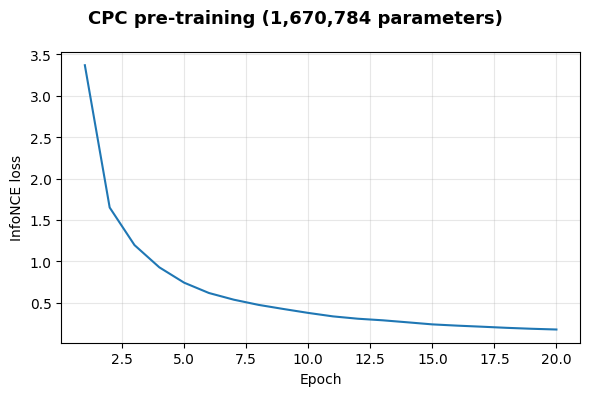

In [7]:
try:
    _ = pretrain_losses[0]
except (NameError, IndexError):
    ckpt = torch.load(os.path.join(CKPT_DIR, 'cpc_last.pt'), map_location=device)
    pretrain_losses = ckpt['losses']

params = sum(p.numel() for p in cpc.parameters())

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pretrain_losses) + 1), pretrain_losses)
plt.xlabel('Epoch'); plt.ylabel('InfoNCE loss')
plt.suptitle(f'CPC pre-training ({params:,} parameters)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 3. Encoder wrapper for probe / fine-tune

The encoder processes the full image in one pass (with the block-diagonal mask), so for downstream tasks we encode the image and mean-pool the 64 patch features.

In [ ]:
class CPCEncoder(nn.Module):
    
    def __init__(self, cpc):
        super().__init__()
        self.encoder = cpc.encoder

    def forward(self, images):
        z = self.encoder(images)          # (B, 64, D)
        return z.mean(dim=1)              # (B, D)


def build_cpc_from_checkpoint():
    m = CPC().to(device)
    ckpt = torch.load(os.path.join(CKPT_DIR, 'cpc_best.pt'), map_location=device)
    m.load_state_dict(ckpt['model'])
    return m

In [9]:
def slope_per_epoch(values, window=5):
    if len(values) < 2:
        return float('inf')
    w = min(window, len(values))
    y = np.array(values[-w:]); x = np.arange(w)
    return float(np.polyfit(x, y, 1)[0])


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

---
# 4. Linear probe on CIFAR-10

Freeze the encoder, train only a linear classifier head on the mean-pooled feature.

In [10]:
class LinearProbe(nn.Module):
    def __init__(self, encoder, num_classes, d_model):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Linear(d_model, num_classes)
        for p in self.encoder.parameters():
            p.requires_grad = False

    def forward(self, images):
        with torch.no_grad():
            h = self.encoder(images)
        return self.head(h)


probe = LinearProbe(CPCEncoder(build_cpc_from_checkpoint()), NUM_CLASSES, D_MODEL).to(device)

params    = sum(p.numel() for p in probe.head.parameters())
params_th = D_MODEL * NUM_CLASSES + NUM_CLASSES
print(f"trainable (head) empirical : {params:,}")
print(f"trainable (head) theory    : {params_th:,}")
print(f"match                      : {params == params_th}")

trainable (head) empirical : 1,290
trainable (head) theory    : 1,290
match                      : True


C:\Users\hugop\AppData\Local\Temp\ipykernel_7908\711145984.py:11: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(block, num_layers=NUM_LAYERS)
C:\Users\hugop\AppData\Local\Temp\ipykernel_7908\711145984.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(block, num_layers=AR_LAYERS)


In [11]:
PROBE_LR = 1e-3

optimizer = torch.optim.AdamW(probe.head.parameters(), lr=PROBE_LR, weight_decay=0.0)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
probe_train_losses, probe_test_losses = [], []
probe_train_accs,   probe_test_accs   = [], []
probe_best_acc = 0.0

for epoch in range(1, PROBE_EPOCHS + 1):
    probe.train(); probe.encoder.eval()
    tr_loss, tr_acc = train_one_epoch(probe, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(probe, test_loader, criterion)
    probe_train_losses.append(tr_loss); probe_test_losses.append(te_loss)
    probe_train_accs.append(tr_acc);   probe_test_accs.append(te_acc)
    print(f"Probe epoch {epoch:2d}/{PROBE_EPOCHS} | "
          f"train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > probe_best_acc:
        probe_best_acc = te_acc
        torch.save({'epoch': epoch, 'model': probe.state_dict(),
                    'train_losses': probe_train_losses, 'test_losses': probe_test_losses,
                    'train_accs':   probe_train_accs,   'test_accs':   probe_test_accs},
                   os.path.join(CKPT_DIR, 'cpc_probe_best.pt'))

    best_epoch = probe_test_accs.index(max(probe_test_accs))
    if (len(probe_test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print()
print(f"best test acc : {max(probe_test_accs)*100:.2f}%")
print(f"converged at  : epoch {probe_test_accs.index(max(probe_test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in probe_test_accs]):.3f} %/epoch")

Probe epoch  1/60 | train 1.9284 29.2% | test 1.8033 32.9%
Probe epoch  2/60 | train 1.8283 32.8% | test 1.7683 33.7%
Probe epoch  3/60 | train 1.7976 33.8% | test 1.7453 35.3%
Probe epoch  4/60 | train 1.7813 34.3% | test 1.7409 34.8%
Probe epoch  5/60 | train 1.7644 35.0% | test 1.7490 34.4%
Probe epoch  6/60 | train 1.7538 34.9% | test 1.7557 34.1%
Probe epoch  7/60 | train 1.7472 35.6% | test 1.7546 34.7%
Probe epoch  8/60 | train 1.7429 35.6% | test 1.7494 34.5%
Probe epoch  9/60 | train 1.7340 36.0% | test 1.7467 35.0%
Probe epoch 10/60 | train 1.7294 36.1% | test 1.7558 34.7%
Probe epoch 11/60 | train 1.7248 36.3% | test 1.7500 34.9%
  early stop : converged (no improvement for 8 epochs)

best test acc : 35.26%
converged at  : epoch 3
final slope   : 0.063 %/epoch


## Curves

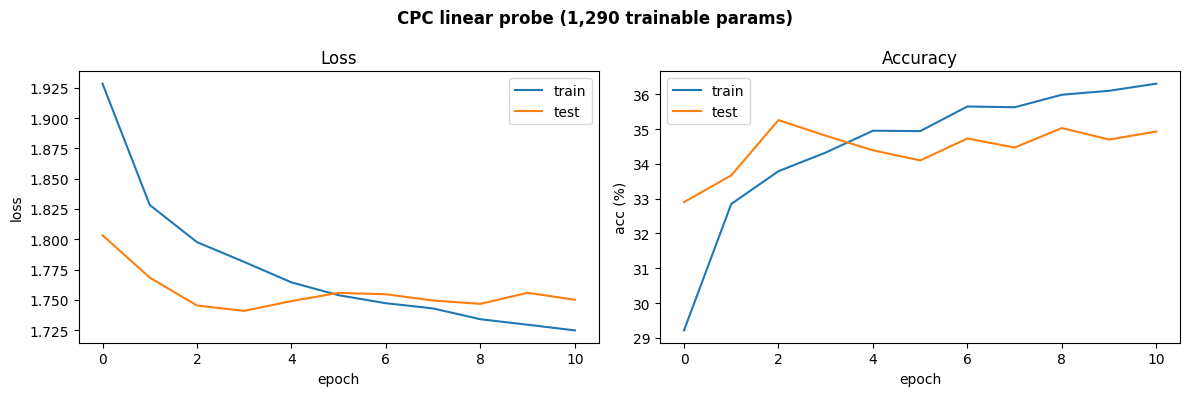

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(probe_train_losses, label='train'); ax1.plot(probe_test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in probe_train_accs], label='train'); ax2.plot([a*100 for a in probe_test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'CPC linear probe ({sum(p.numel() for p in probe.head.parameters()):,} trainable params)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Results

Plot 10 random predictions from the test set

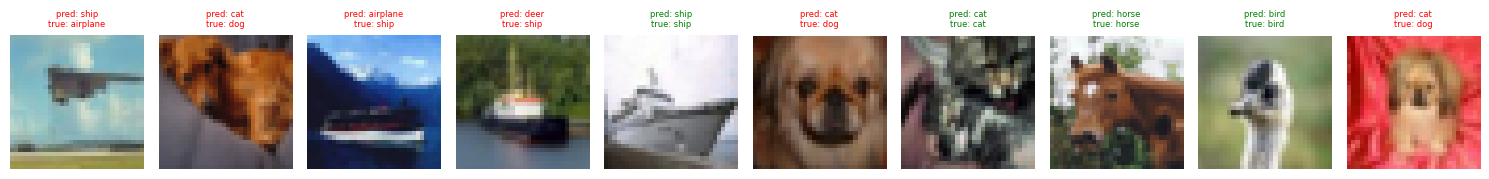

In [13]:
probe.eval()
classes = test_dataset.classes
indices = torch.randint(0, len(test_dataset), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = test_dataset[idx]
    with torch.no_grad():
        logits = probe(img.unsqueeze(0).to(device))
        pred   = logits.argmax(dim=1).item()
    axes[i].imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {classes[pred]}\ntrue: {classes[true_label]}",
                       fontsize=6, color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

---
# 6. Full fine-tune on CIFAR-10

Unfreeze the encoder, train everything end-to-end.

In [14]:
class FullFineTune(nn.Module):
    def __init__(self, encoder, num_classes, d_model):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Linear(d_model, num_classes)

    def forward(self, images):
        h = self.encoder(images)
        return self.head(h)


ft = FullFineTune(CPCEncoder(build_cpc_from_checkpoint()), NUM_CLASSES, D_MODEL).to(device)
print(f"trainable params : {sum(p.numel() for p in ft.parameters()):,}")

trainable params : 1,205,642


C:\Users\hugop\AppData\Local\Temp\ipykernel_7908\711145984.py:11: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(block, num_layers=NUM_LAYERS)
C:\Users\hugop\AppData\Local\Temp\ipykernel_7908\711145984.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(block, num_layers=AR_LAYERS)


In [15]:
FT_LR = 1e-4

optimizer = torch.optim.AdamW(ft.parameters(), lr=FT_LR, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
ft_train_losses, ft_test_losses = [], []
ft_train_accs,   ft_test_accs   = [], []
ft_best_acc = 0.0

for epoch in range(1, FT_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(ft, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(ft, test_loader, criterion)
    ft_train_losses.append(tr_loss); ft_test_losses.append(te_loss)
    ft_train_accs.append(tr_acc);   ft_test_accs.append(te_acc)
    print(f"FT epoch {epoch:2d}/{FT_EPOCHS} | "
          f"train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > ft_best_acc:
        ft_best_acc = te_acc
        torch.save({'epoch': epoch, 'model': ft.state_dict(),
                    'train_losses': ft_train_losses, 'test_losses': ft_test_losses,
                    'train_accs':   ft_train_accs,   'test_accs':   ft_test_accs},
                   os.path.join(CKPT_DIR, 'cpc_ft_best.pt'))

    best_epoch = ft_test_accs.index(max(ft_test_accs))
    if (len(ft_test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print()
print(f"best test acc : {max(ft_test_accs)*100:.2f}%")
print(f"converged at  : epoch {ft_test_accs.index(max(ft_test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in ft_test_accs]):.3f} %/epoch")

FT epoch  1/60 | train 1.6585 38.6% | test 1.4474 47.8%
FT epoch  2/60 | train 1.3786 49.9% | test 1.2846 53.2%
FT epoch  3/60 | train 1.2709 54.1% | test 1.1837 57.1%
FT epoch  4/60 | train 1.1897 57.3% | test 1.1293 59.3%
FT epoch  5/60 | train 1.1314 59.3% | test 1.0907 60.7%
FT epoch  6/60 | train 1.0864 61.2% | test 1.0384 62.9%
FT epoch  7/60 | train 1.0490 62.5% | test 0.9860 64.7%
FT epoch  8/60 | train 1.0162 63.7% | test 0.9656 65.9%
FT epoch  9/60 | train 0.9934 64.6% | test 0.9227 66.9%
FT epoch 10/60 | train 0.9660 65.4% | test 0.9160 68.0%
FT epoch 11/60 | train 0.9431 66.7% | test 0.9094 67.8%
FT epoch 12/60 | train 0.9214 67.3% | test 0.8733 69.0%
FT epoch 13/60 | train 0.9100 67.7% | test 0.8633 69.0%
FT epoch 14/60 | train 0.8939 68.4% | test 0.8423 70.5%
FT epoch 15/60 | train 0.8786 68.9% | test 0.8288 70.7%
FT epoch 16/60 | train 0.8643 69.3% | test 0.8296 70.8%
FT epoch 17/60 | train 0.8543 69.7% | test 0.8587 69.8%
FT epoch 18/60 | train 0.8400 70.4% | test 0.840

## Curves

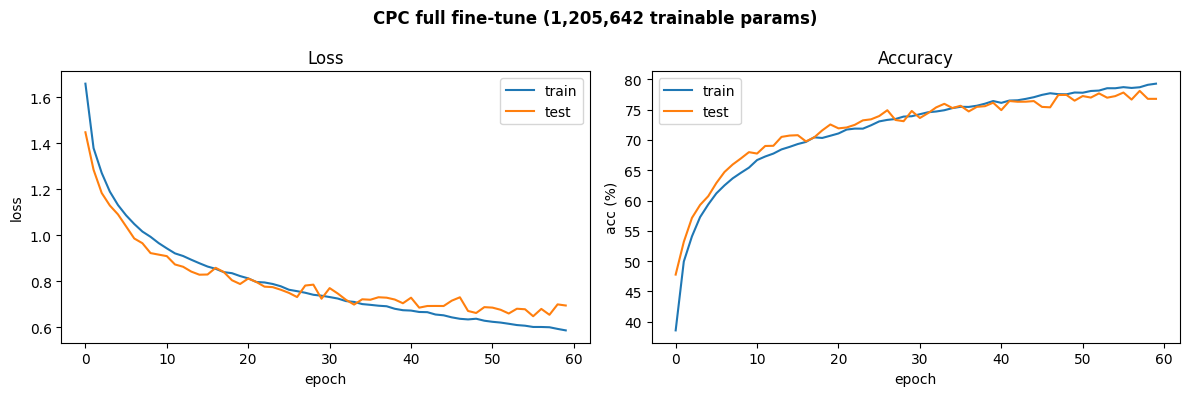

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ft_train_losses, label='train'); ax1.plot(ft_test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in ft_train_accs], label='train'); ax2.plot([a*100 for a in ft_test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'CPC full fine-tune ({sum(p.numel() for p in ft.parameters()):,} trainable params)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Results

Plot 10 random predictions from the test set

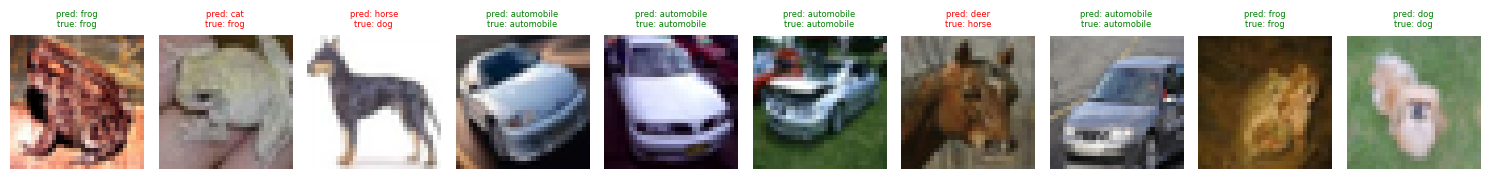

In [17]:
ft.eval()
classes = test_dataset.classes
indices = torch.randint(0, len(test_dataset), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = test_dataset[idx]
    with torch.no_grad():
        logits = ft(img.unsqueeze(0).to(device))
        pred   = logits.argmax(dim=1).item()
    axes[i].imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {classes[pred]}\ntrue: {classes[true_label]}",
                       fontsize=6, color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()